2a. Preprocessing (data cleaning), feature extraction, feature selection, machine learning, model evaluation, post-processing

2b. 

3a. With unbalanced classes, overrepresented classes would dominate the score.

3b. 

3c. 

4a. Cross validation 

4b. By training models on different train/test splits and averaging the result, the chance of getting outlier performance on the given dataset is lowered.

4c. 

# ERP analysis

In [1]:
import glob
import mne
from matplotlib import pyplot as plt
import numpy as np
import os
import seaborn as sns
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import cross_val_score
import warnings

warnings.simplefilter(action='ignore', category=RuntimeWarning)
mne.set_log_level('WARNING')
np.random.seed(42)

## Exercise 1: Download data

The dataset contains three subjects, one session each. In the main part of the session, an auditory oddball paradigm was done. For two different stimulus onset asynchrony (SOA) values, a fast and a slow condition, 80 trials of oddball ERP data were collected. Within a trial, you should find 90 stimuli (75 low-pitched non-targets and 15 high-pitched targets). 

1. Retrieve the data from [Zenodo](https://zenodo.org/record/4066633) and store it at a convenient location locally, e.g., your Downloads folder;
1. In the code snippet below, set the `data_path` to point to where the `eeg_tutorial_erp_data` folder lives;

In [2]:
data_path = os.path.join(os.path.expanduser("~"), "Downloads", "eeg_tutorial_erp_data")

session_list = ["erp_subject_1", "erp_subject_2", "erp_subject_3"]
condition_list = ["fast", "slow"]

## Exercise 2: Load raw data

Next, we load the downloaded dataset using MNE. Explore the content of the dataset. 
1. How many EEG channels are in the dataset?
2. What are the names of these EEG channels?
3. What is the sampling rate? 

**Hint**: Look into the `raw_data` variable, take one of the sessions and conditions, and print the `info` attribute of the items in it.

In [3]:
# Loop over subjects/sessions and conditions
raw_data = dict()
for session in session_list:
    for condition in condition_list:
        
        # Find files
        search_path = os.path.join(data_path, session, f"*{condition}.vhdr")
        eeg_filepaths = sorted(glob.glob(search_path))
        print(f'Loading {len(eeg_filepaths)} files matching {search_path}')

        # Load the data
        arr = []
        for eeg_filepath in eeg_filepaths:
            
            # Load EEG data stored in BrainVision format
            raw = mne.io.read_raw_brainvision(eeg_filepath, misc=['EOGvu', 'x_EMGl', 'x_GSR', 'x_Respi', 'x_Pulse', 'x_Optic'])
            
            # Set the electrode layout to standard international 10-20 system
            raw.set_montage('standard_1020').load_data()
            
            # Remove non-EEG channels
            raw.pick_types(eeg=True)
            
            # Add to array
            arr.append(raw)
        
        # Add to data stack
        if session not in raw_data:
            raw_data[session] = dict()
        if condition not in raw_data[session]:
            raw_data[session][condition] = dict()
        raw_data[session][condition] = mne.concatenate_raws(arr)

print("Done!")

Loading 20 files matching /home/robert/Downloads/eeg_tutorial_erp_data/erp_subject_1/*fast.vhdr
Loading 20 files matching /home/robert/Downloads/eeg_tutorial_erp_data/erp_subject_1/*slow.vhdr
Loading 20 files matching /home/robert/Downloads/eeg_tutorial_erp_data/erp_subject_2/*fast.vhdr
Loading 20 files matching /home/robert/Downloads/eeg_tutorial_erp_data/erp_subject_2/*slow.vhdr
Loading 20 files matching /home/robert/Downloads/eeg_tutorial_erp_data/erp_subject_3/*fast.vhdr
Loading 20 files matching /home/robert/Downloads/eeg_tutorial_erp_data/erp_subject_3/*slow.vhdr
Done!


Fast and slow both sample at 1000Hz with 31 EEG channels.

## Exercise 3: Preprocess data
Next, we preprocess the continuous data. We bandpass filter the data, slice the data into epochs around events, and baseline correct and decimate the epochs. 

1. What is the sampling frequency of the epoched data? Why this number?
1. What events are in the data?
1. How many epochs do we have per event?
1. What happens if you set epoch rejection? **Hint**: Look at the result of the previous question.
1. What happens when you bandpass the data after slicing instead of before? **Hint**: Visualize one channel of one epoch and compare before and after.


In [59]:
raw_stim_ids = {"Stimulus/S  1": 1, "Stimulus/S 21": 2}
class_ids = {"Target": 2, "Non-target": 1}

filter_band = (1.5, 16)  # Hz
baseline_ival = None  # (-.2, 0)  # s
reject = None # dict(eeg=60 * 1e-6)  # V
decimate = 10  # factor

# Loop over subjects/sessions and conditions
epo_data = dict()
for session in session_list:
    for condition in condition_list:
        raw = raw_data[session][condition].copy()
            
        # Bandpass filter
        raw = raw.filter(filter_band[0], filter_band[1])

        # Read events from the markers/annotations in the data
        events = mne.events_from_annotations(raw, event_id=raw_stim_ids)[0]

        # Slice to epochs 
        epo = mne.Epochs(raw, events, event_id=class_ids, baseline=baseline_ival, decim=decimate, reject=reject, proj=False, preload=True)

        # Bandpass filter after epoching
        # epo = epo.filter(filter_band[0], filter_band[1])

        # Add to data stack
        if session not in epo_data:
            epo_data[session] = dict()
        if condition not in epo_data[session]:
            epo_data[session][condition] = dict()
        epo_data[session][condition] = epo
        

1. The sampling rate is now 100Hz, since the subsampling rate (decimate) is 10.
2. There are 1500 non-target and 300 target events.
3. There are 1044 epochs per channel 
```python
ch = epo_data["erp_subject_1"]["fast"].pick_channels(["Fp1"]).to_data_frame()
len(ch["epoch"].unique())
```
5. Setting the epoch rejection filters the amount of events down to 1044

In [61]:
ch = epo_data["erp_subject_1"]["fast"].pick_channels(["Fp1"])

In [62]:
x = ch.to_data_frame()
channel = x[x["condition"] == "Target"]["Fp1"]
#plt.plot(channel)

len(x["epoch"].unique())

1800

## Exercise 4: ERP plots

ERPs are computed by averaging all epochs belonging to the same condition. We plot both time-series (the ERP across time), as well as topoplots (the ERP across channels).

1. Explore the scalp topography at other time points. At which time points can you see peaks in the ERPs?
3. At which locations are these peaks dominant?
4. Does the non-target response show similar peaks?

IndexError: index 0 is out of bounds for axis 0 with size 0

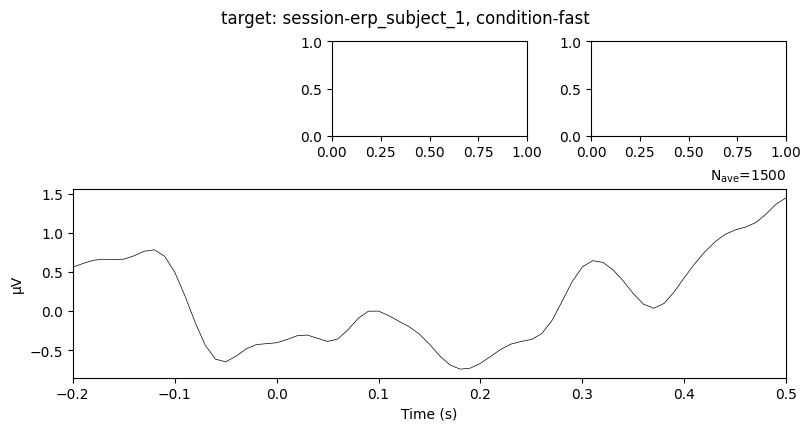

In [63]:
scalp_times = (0.1, 0.2, 0.3)

for session in session_list:
    for condition in condition_list:
        epo = epo_data[session][condition]
        
        # Compute ERP
        t_evoked = epo['Non-target'].average()
        
        # Plot ERP
        t_evoked.plot_joint(title=f'target: session-{session}, condition-{condition}', times=scalp_times)     
        

In [ ]:
# Answer here

## Exercise 5: Classification across time (spatial filter) 

We want to classify target vs. non-target epochs. The data has the following dimensionality: $\mathbf{X}_i \in \mathbb{R}^{N_c \times N_t}$ for the $i$th epoch, with $N_c$ channels and $N_t$ EEG samples (time points). 

Here, we will only use spatial information for classification. That is, we decode at each sample separately, and use the $N_c$-dimensional feature vector to classify between target and non-target epochs.

1. What is the most informative time interval relative to the stimulus onset? 
1. What is the grand average classification performance at the best-performing time interval?
1. Why can you observe an AUC performance above 0.5 for some time points before $t=0$? 

In [ ]:
clf_times = np.arange(-0.2, 0.51, 0.01)

fig, axes = plt.subplots(len(session_list), 1, figsize=(15, 6), sharey=True, sharex=True)

scores = np.zeros((len(session_list), len(condition_list), clf_times.shape[0]))
for s_i, session in enumerate(session_list):
    
    ax = axes[s_i] if len(session_list) > 1 else axes
    
    for c_i, condition in enumerate(condition_list):
        
        # Compute scores with cross_val_score from sklearn
        for t_i, clf_time in enumerate(clf_times):
            
            # Extract the data
            epo = epo_data[session][condition]
            X = epo.get_data()[:, :, epo.time_as_index(clf_time)].squeeze()
            y = epo.events[:, 2]
            
            # Initialize classifier
            lda = LDA(solver='lsqr', shrinkage='auto')
            
            # Evaluate classifier, save average score over folds
            scores[s_i, c_i, t_i] = cross_val_score(lda, X, y, cv=5, scoring='roc_auc').mean()
            
        # Plot scores over time
        ax.plot(clf_times, scores[s_i, c_i, :], label=f'Condition {condition}')
        
    ax.set_title(f'AUC scores for {session}')
    ax.set_ylabel('AUC')
    
ax.set_xlabel('Time relative to stimulus onset (s)')
ax.legend()


In [ ]:
# Answer here

## Exercise 6: Classification across channels (temporal filter)

Next, we train one classifier per channel, but provide it with information from multiple time points of that channel. Thus our feature vector would be $N_t$-dimensional. 

Because neighboring time samples contain very similar information, we use a common feature extraction step for ERP: we average the signal in several time intervals (`clf_ival_boundaries`). 

1. What is the most informative channel? 
1. What is the grand average classification performance at the best-performing channel?


In [ ]:
def get_jumping_means(epo, boundaries):
    shape_orig = epo.get_data().shape
    X = np.zeros((shape_orig[0], shape_orig[1], len(boundaries) - 1))
    for i in range(len(boundaries)-1):
        idx = epo.time_as_index((boundaries[i], boundaries[i + 1]))
        idx_range = list(range(idx[0], idx[1]))
        X[:, :, i] = epo.get_data()[:, :, idx_range].mean(axis=2)
    return X

In [ ]:
clf_ival_boundaries = np.array([0.1, 0.17, 0.23, 0.3, 0.41, 0.5])

fig, axes = plt.subplots(len(session_list), len(condition_list), figsize=(12,8))

scores = np.zeros((len(session_list), len(condition_list), len(epo.ch_names)))
for s_i, session in enumerate(session_list):
    for c_i, condition in enumerate(condition_list):
        
        ax = axes[c_i] if len(session_list) == 1 else axes[s_i, c_i]
        
        # Compute scores with cross_val_score from sklearn
        for ch_i, ch_name in enumerate(epo.ch_names):
            
            # Extract the data
            epo = epo_data[session][condition]
            X = get_jumping_means(epo.copy().pick([ch_name]), clf_ival_boundaries).squeeze()
            y = epo.events[:, 2]
            
            # Initialize classifier
            lda = LDA(solver='lsqr', shrinkage='auto')
            
            # Evaluate classifier, save average score over folds
            scores[s_i, c_i, ch_i] = cross_val_score(lda, X, y, cv=5, scoring='roc_auc').mean()
            
        # Plot scores over space
        im, cn = mne.viz.plot_topomap(scores[s_i, c_i, :], epo.info, axes=ax, cmap='RdBu_r', show=False, vlim=(0,1)) 
        ax.set_title(f'AUC for {session}, condition {condition}')
        plt.colorbar(im, ax=ax)


In [ ]:
# Answer here

## Exercise 7: Classification across space and time (spatio-temporal filter)

The above two analyses provide great insight into where the decodable information is. In practice, we usually do not split our features into spatial and temporal domains, but instead integrate information from both domains into one spatio-temporal feature vector of $N_c \times N_t$. 

Classifiers like LDA expect a feature *vector*, not a spatio-temporal data *matrix*. To get the feature *vector*, we simply concatenate the five temporal features for every channel, that is, we **flatten** the feature matrix into a feature vector. Note, LDA does not care about the order of the features. 

1. What is the grand average performance? Is it higher than the previous two analyses? 
1. We cannot create the previous nice plots with decoding across space and time. Can you come up with another way to inspect the results to answer, roughly, where the decodable information is located (both in space and in time)?

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(5,3))

scores = np.zeros((len(session_list), len(condition_list)))
for s_i, session in enumerate(session_list):
    for c_i, condition in enumerate(condition_list):
        
        # Extract the data
        epo = epo_data[session][condition]
        X = get_jumping_means(epo, clf_ival_boundaries).squeeze()
        y = epo.events[:, 2]

        # Flatten the features
        X = X.reshape((y.size, -1))
        
        # Initialize classifier
        lda = LDA(solver='lsqr', shrinkage='auto')
        
        # Evaluate classifier, save average score over folds
        scores[s_i, c_i] = cross_val_score(lda, X, y, cv=5, scoring='roc_auc').mean()
    
    # Plot scores as scatter
    ax.scatter(session, scores[s_i, 0], label='Condition fast', color='b', marker='x')
    ax.scatter(session, scores[s_i, 1], label='Condition slow', color='r', marker='x')
    if s_i == 0:
        plt.legend()
plt.title('AUC for spatio-temporal classification')


In [ ]:
# Answer here

## Exercise 8 (optional): Regularization and learning curve
1. How does performance change if the LDA uses no regularization? 
1. Does regularization make a difference if you train your LDA model on much smaller data sets, e.g., on data of 2 trials only (corresponding to 30 targets and 150 non-targets)? 
1. Can you plot the effect of shrinkage regularization as a function of data set size?

## Exercise 9 (optional): Permutation testing
You might observe that in the previous analyses, sometimes the classifier is performing around chance level (50%). Despite that (under an engineering perspective) one may conclude the classifier did a poor job, one (under a neuroscientific perspective) can be very interested in whether it is *just* above chance level, as it means that there is just some decodable information at that location (being in time or space). A common and very flexible way of significance testing in such scenario is to perform **permutation testing**. 

From Wikipedia: "A permutation test (also called a randomization test, re-randomization test, or an exact test) is a type of statistical significance test in which the distribution of the test statistic under the null hypothesis is obtained by calculating all possible values of the test statistic under all possible rearrangements of the observed data points."

To put it into context. In our dataset we are interested in whether we can decode target versus non-target from the data. For this, we got data samples that are tuples containing $(X_i, y_i)$, the data and the target label. Now, within a permutation test, we randomize (permute) the particular structure we are originally interested in, in this case the pairing of $X_i$ with $y_i$. Concretely, here we can basically randomize this by shuffling the vector $y=[y_1, y_2, ..., y_N]$ to e.g. $y_{permuted}=[y_3, y_N, ..., y_2]$. We perform the same analysis on this shuffled dataset, and save its result. If we do this many times (in the order of 1000 times), we obtain a so-called **permutation distribution** of the test statistic (e.g. classification performance). We can then look-up where in this distribution we can find our original test statistic (i.e., the one without shuffling the labels). We say that the original test statistic is significantly above chance if no more than 5% of the samples in the permutation distribution are higher than the original test statistic ($\alpha=.05$).

1. Implement this permutation test for the decoding over time at time interval -50ms. **Hint:** it requires you to write a loop over the analysis that is provided already, and to shuffle the labeling in `y` e.g. with `np.random.permutation()`;
1. Plot the permutation distribution. What does it look like, can you explain its shape?
1. Is the decoding at this time interval significant?

In [ ]:
# Answer here